Trying to find fastest way to import file data

In [24]:
import pandas as pd
import time

In [25]:
start=time.time()
df = pd.read_csv("C:/Users/IMG/Documents/ocean-timeseries-ml/data/raw/xsec_south")
end=time.time()
print(df.head())
print("time for pd.read_csv():", end - start)

   34.2500    0.3832  20.744  39.056  0.3500  0.1979
0   34.2500    1.1495  20.748  39.055  0.3368  0....
1   34.2500    1.9158  20.753  39.053  0.3203  0....
2   34.2500    3.0652  20.760  39.049  0.2958  0....
3   34.2500    4.5978  20.764  39.047  0.2824  0....
4   34.2500    6.1304  20.766  39.046  0.2754  0....
time for pd.read_csv(): 30.117581844329834


In [26]:
start=time.time()
raw = pd.read_csv("C:/Users/IMG/Documents/ocean-timeseries-ml/data/raw/xsec_south", sep=r"\s+", header=None)  # fast read
end=time.time()
print(raw.head())
print("time for pd.read_csv():", end - start)

       0       1       2       3       4       5
0  34.25  0.3832  20.744  39.056  0.3500  0.1979
1  34.25  1.1495  20.748  39.055  0.3368  0.1997
2  34.25  1.9158  20.753  39.053  0.3203  0.2021
3  34.25  3.0652  20.760  39.049  0.2958  0.2060
4  34.25  4.5978  20.764  39.047  0.2824  0.2083
time for pd.read_csv(): 90.86028456687927


conclusion:  pd.read_csv with just filename was faster

Function to load dataset into arrays that are easy to access and remember for future analysis translated from matlab

In [41]:
import numpy as np
import pandas as pd


def load_ocean_data(filename, nz, nx, nt, latitude, start_time, time_resolution=1):
    """Direct translation of the MATLAB load_ocean_data.

    File columns: [lon, depth, temp, salinity, u, v].
    Returns a dict with 3D fields indexed [depth, lon, time] (like a struct).
    """
    raw = pd.read_csv(filename).values  # [nx*nz*nt, 6]

    if raw.shape[0] != nx * nz * nt:
        raise ValueError("Data length does not match nx*nz*nt. Check input values.")

    temperature = np.zeros((nz, nx, nt))
    salinity    = np.zeros((nz, nx, nt))
    u           = np.zeros((nz, nx, nt))
    v           = np.zeros((nz, nx, nt))
    depth       = np.zeros((nz, nx))
    lon         = np.zeros((nz, nx))

    for t in range(nt):
        frame = raw[t*nx*nz:(t+1)*nx*nz, :]            # [nz*nx, 6]
        # MATLAB reshape is column-major -> order="F"
        temperature[:, :, t] = frame[:, 2].reshape(nz, nx, order="F")
        salinity[:, :, t]    = frame[:, 3].reshape(nz, nx, order="F")
        u[:, :, t]           = frame[:, 4].reshape(nz, nx, order="F")
        v[:, :, t]           = frame[:, 5].reshape(nz, nx, order="F")
        if t == 0:
            depth = frame[:, 1].reshape(nz, nx, order="F")
            lon   = frame[:, 0].reshape(nz, nx, order="F")

    # Generate time vector
    time_vec = pd.date_range(start=start_time, periods=nt, freq=f"{time_resolution}h")

    # --- Adjust for leap years across multi-year datasets ---
    if time_resolution == 1:  # only valid for hourly data
        # Find all Feb 29ths at 00:00 in the time vector
        is_feb29 = (time_vec.month == 2) & (time_vec.day == 29) & (time_vec.hour == 0)
        idx_feb29 = np.where(is_feb29)[0]

        remove = np.zeros(len(time_vec), dtype=bool)
        for idx in idx_feb29:
            end = idx + 24                 # this hour plus the next 23
            if end <= len(time_vec):
                remove[idx:end] = True

        if remove.any():
            keep = ~remove
            temperature = temperature[:, :, keep]
            salinity    = salinity[:, :, keep]
            u           = u[:, :, keep]
            v           = v[:, :, keep]
            time_vec    = time_vec[keep]
            nt          = temperature.shape[2]   # update nt after removal

    return {
        "temp": temperature, "sal": salinity, "u": u, "v": v,
        "depth": depth, "lon": lon, "time": time_vec,
        "lat": latitude, "nx": nx, "nz": nz, "nt": nt,
        "timeRes": time_resolution,
    }

In [43]:


d = load_ocean_data("C:/Users/IMG/Documents/ocean-timeseries-ml/data/raw/xsec_south",
                    nz=39, nx=23, nt=26304, latitude=31.8,
                    start_time=pd.Timestamp("2016-01-01 13:00"),
                    time_resolution=1)

temp shape [depth, lon, time]: (39, 23, 26280)
surface temp, westernmost, first hour: 20.744 (expect ~29.038) depth: 0.38
deepest temp, westernmost, first hour: 14.162 (expect ~14.125) depth: 630.67
first time: 2016-01-01 13:00:00 | last time: 2019-01-01 12:00:00


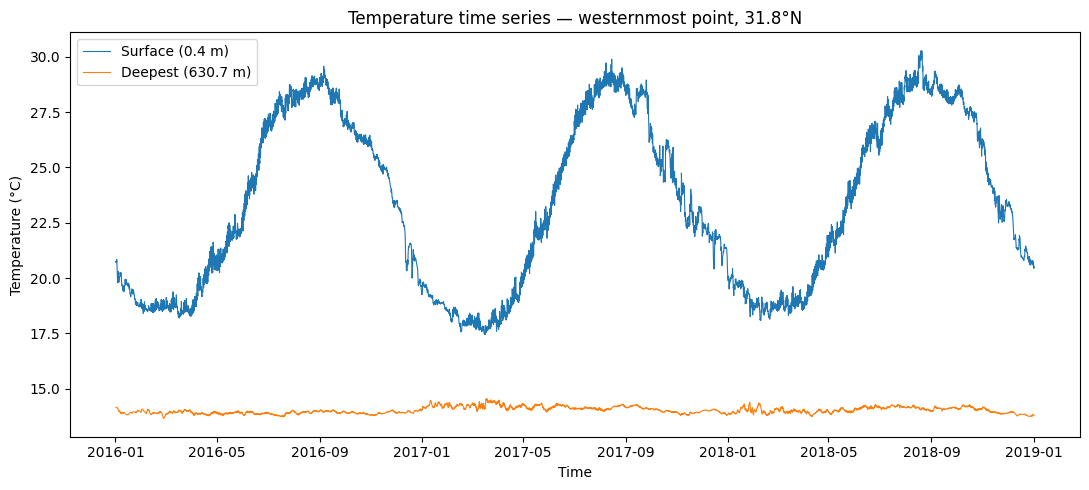

In [47]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Quick sanity checks ---
print("temp shape [depth, lon, time]:", d["temp"].shape)
print("surface temp, westernmost, first hour:", round(d["temp"][0, 0, 0], 3), "(expect ~29.038)", "depth:", round(d["depth"][0, 0], 2))
print("deepest temp, westernmost, first hour:", round(d["temp"][-1, 0, 0], 3), "(expect ~14.125)", "depth:", round(d["depth"][-1, 0], 2))
print("first time:", d["time"][0], "| last time:", d["time"][-1])

# --- Pull two time series at the westernmost longitude (j=0) ---
surface = d["temp"][0, 0, :]     # depth index 0  = surface
deepest = d["temp"][-1, 0, :]    # depth index -1 = deepest level
time = d["time"]

# --- Plot ---
plt.figure(figsize=(11, 5))
plt.plot(time, surface, label=f"Surface ({d['depth'][0, 0]:.1f} m)", linewidth=0.8)
plt.plot(time, deepest, label=f"Deepest ({d['depth'][-1, 0]:.1f} m)", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title(f"Temperature time series — westernmost point, {d['lat']}°N")
plt.legend()
plt.tight_layout()
plt.show()